<a href="https://colab.research.google.com/github/arunpalanoor/esp32-edge-playground/blob/main/mnist_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [42]:
# Import the necessary libraries.
import numpy as np
import matplotlib.pyplot as plt

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

# Data Set

In [43]:
# Import the MNIST data set.
from keras.datasets import mnist

In [44]:
# Load and preprocess the data.
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Pre-process data

In [45]:
# Normalise the pixel values to be between 0 and 1.
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

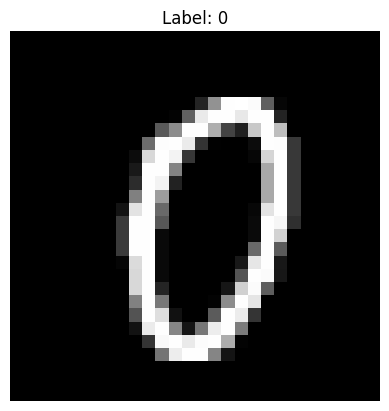

In [47]:
# View an example.
plt.imshow(X_train[1000].reshape(28, 28),
           cmap='gray')
plt.title(f"Label: {y_train[1000]}")
plt.axis('off')
plt.show()

# Train-Validation-Test Split

In [48]:
# View output.
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape:  (60000, 28, 28)
X_test shape:  (10000, 28, 28)


In [49]:
# Flatten the images.
X_train = X_train.reshape((-1, 28*28))
X_test = X_test.reshape((-1, 28*28))

In [50]:
# View output.
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape:  (60000, 784)
X_test shape:  (10000, 784)


In [51]:
# One-hot encode the labels.
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [52]:
# View the output.
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

y_train shape:  (60000, 10)
y_test shape:  (10000, 10)


In [53]:
# Split the training data into training and validation sets.
# 50,000 samples for training, rest for validation
split = 50000

In [54]:
x_val = X_train[split:]
y_val = y_train[split:]
X_train = X_train[:split]
y_train = y_train[:split]

In [55]:
# View output.
print("x_val shape: ", x_val.shape)
print("y_val shape: ", y_val.shape)
print("X_train shape: ", X_train.shape)
print("y_train shape: ", y_train.shape)

x_val shape:  (10000, 784)
y_val shape:  (10000, 10)
X_train shape:  (50000, 784)
y_train shape:  (50000, 10)


# Model

In [56]:
# Define a function to create a neural network model.
def create_model(num_layers):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(28*28,)))

    # Add additional hidden layers based on the num_layers parameter.
    for _ in range(num_layers - 1):
        model.add(Dense(128, activation='relu'))

    model.add(Dense(10, activation='softmax'))

    # Compile the model.
    model.compile(optimizer=Adam(), loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [57]:
num_layers = 3
model = create_model(num_layers)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
# Train the model.
model.fit(X_train, y_train,
            epochs=15,
            batch_size=128,
            validation_data=(x_val, y_val),
            verbose=0)

In [59]:
# Evaluate the model.
_, accuracy = model.evaluate(X_test, y_test, verbose=0)

In [60]:
print(f"Model with {num_layers} layers - Test accuracy: {accuracy}")

Model with 3 layers - Test accuracy: 0.9745000004768372


# Test Model with real examples

In [74]:
#load an png image as numpy array

from PIL import Image

test_image = Image.open('test_image3.png')
test_image = test_image.convert('L')

In [75]:
# Normalise the pixel values to be between 0 and 1.

test_image = test_image.resize((28, 28))
test_image = np.array(test_image)
test_image = test_image.astype('float32') / 255.0
test_image = np.array(1-test_image)

In [76]:
print(test_image.shape)

(28, 28)


In [72]:
test_image

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

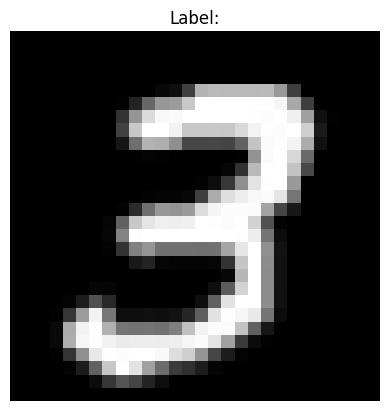

In [77]:
# View an example.
plt.imshow(test_image,
           cmap='gray')
plt.title(f"Label:")
plt.axis('off')
plt.show()

In [78]:
#predict test_image using model
test_image_shaped = test_image.reshape((1, 28*28))
test_image_shaped = test_image_shaped.astype('float32') #/ 255.0

prediction = model.predict(test_image_shaped)
print(max(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[1.2670798e-27 1.3179075e-18 1.8034552e-19 1.0000000e+00 5.6152621e-27
 1.4618944e-13 1.9451136e-32 4.1402243e-22 1.1965134e-17 2.8496696e-15]


In [79]:
#get the index of the max of prediction
print(np.argmax(prediction))

3


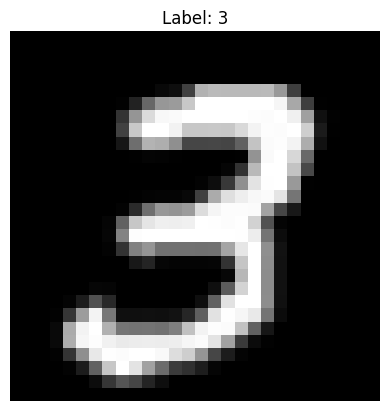

In [80]:
# View an example.
plt.imshow(test_image,
           cmap='gray')
plt.title(f"Label: {np.argmax(prediction)}")
plt.axis('off')
plt.show()

# Save model

In [82]:
# Save the model as keras h5 file
model.save('model.keras')